In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import copy

import sys, os
sys.path.append('../SNR_timeseries/')

import SNRtsGlobals as glob
import SNRtsUtils as utils
import waveforms as wf
import SNRtsCompute as tsCompute

In [2]:
try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd().parent
DATA_ROOT = REPO_ROOT / "data" / "example"
SNR_TIMESERIES_DIR = DATA_ROOT / "snr_timeseries"
ASDS_DIR = DATA_ROOT / "psds" 

EVENT_INDEX = 0
DETECTORS = ("H1", "L1", "V1")
RATIO_DETECTOR = "L1"

In [3]:
# Load an example event, with the characteristics of GW190814
events=utils.load_population(SNR_TIMESERIES_DIR / "detected_events_0_to_1.hdf5")
event = {key: value[EVENT_INDEX] for key, value in events.items()}
for key, value in event.items():
    print(f"{key}: {value}")

# Initialize the waveform object
mywf = wf.LAL_WF('IMRPhenomXHM', is_HigherModes=True)

Mc: 6.417278155742411
Phicoal: 2.9405857459045484
chi1z: 2.5977829987364768e-05
chi2z: 0.024792867274431425
dL: 0.23269868857798015
dec: -0.438543355218072
eta: 0.09005408482473697
iota: 0.8820913870402034
m1_src: 23.310761205456593
m2_src: 2.5913772648540925
psi: 0.4638945177266378
ra: 0.22645568759396095
snr: 28.65009415050454
tGPS: 1249852257.0
tcoal: 0.7796187609352992


In [4]:
# Select as detectors LIGO and Virgo
LVdetectors = {det:copy.deepcopy(glob.detectors[det]) for det in ['L1', 'H1', 'Virgo']}
print('Using detectors '+str(list(LVdetectors.keys())))
# We use the asds corresponding to the design sensitivity of the detectors, which are included in the repository
LVdetectors['L1']['psd_path'] = ASDS_DIR / 'LIGO-T2000012-v1-LIGO_design.txt'
LVdetectors['H1']['psd_path'] = ASDS_DIR / 'LIGO-T2000012-v1-LIGO_design.txt'
LVdetectors['Virgo']['psd_path'] = ASDS_DIR / 'LIGO-T2000012-v1-Vigo_design.txt'
# Initialize the SNR timeseries object
ts_simulator = tsCompute.simulate_SNR_timeseries(LVdetectors, 
                 is_ASD=True, # the asds are given in ASD units, not PSD
                 fmin=10., # in Hz, starting frequency of the analysis
                 fmax=4096., # in Hz, ending frequency of the analysis
                 time_interval=50., # in ms, around the merger time
                 df_integrals = 1./4096., # in Hz, used for the integrals in the SNR computation
                 individual_modes=['22', '33', '44'],  # Specify the modes to compute SNR for
                 reference_detector='L1'  # Specify the reference detector
                )

Using detectors ['L1', 'H1', 'Virgo']


In [5]:
# Now inject the signal and compute the SNR timeseries for the event
SNR_ts, SNR_sq_opt = ts_simulator.injectSignal(event, # the event to inject, as loaded from the population file
                                                mywf, # the waveform object
                                                df=1./8. # in Hz, used for the waveform generation
                                                )

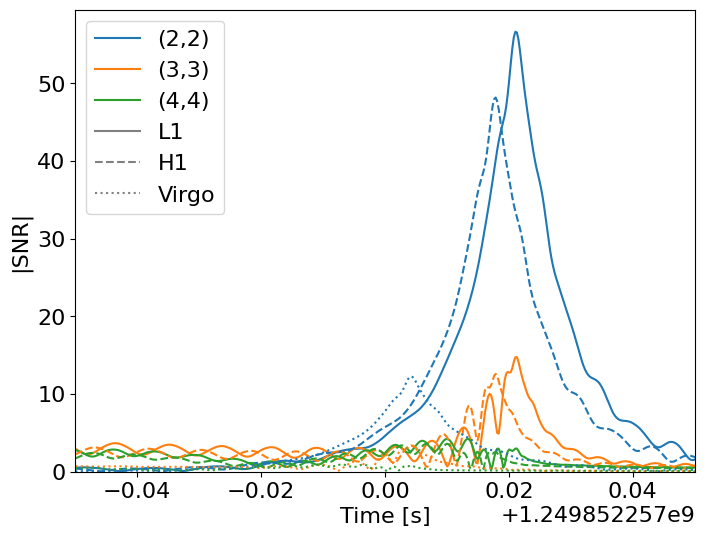

In [6]:
# Lets look at the output SNR timeseries for two detectors
fig, ax = plt.subplots(figsize=(8, 6))
# Increase the font size of the ticks
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=16)
ax.xaxis.offsetText.set_fontsize(16)

ax.plot(SNR_ts['tgrid'], abs(SNR_ts['L1']['22']), label='(2,2)', color='C0')
ax.plot(SNR_ts['tgrid'], abs(SNR_ts['L1']['33']), label='(3,3)', color='C1')
ax.plot(SNR_ts['tgrid'], abs(SNR_ts['L1']['44']), label='(4,4)', color='C2')

ax.plot(SNR_ts['tgrid'], abs(SNR_ts['H1']['22']), color='C0', linestyle='dashed')
ax.plot(SNR_ts['tgrid'], abs(SNR_ts['H1']['33']), color='C1', linestyle='dashed')
ax.plot(SNR_ts['tgrid'], abs(SNR_ts['H1']['44']), color='C2', linestyle='dashed')

ax.plot(SNR_ts['tgrid'], abs(SNR_ts['Virgo']['22']), color='C0', linestyle='dotted')
ax.plot(SNR_ts['tgrid'], abs(SNR_ts['Virgo']['33']), color='C1', linestyle='dotted')
ax.plot(SNR_ts['tgrid'], abs(SNR_ts['Virgo']['44']), color='C2', linestyle='dotted')

# Add dashed lines to the legend to indicate the detector
ax.plot([], [], color='gray', linestyle='solid', label='L1')
ax.plot([], [], color='gray', linestyle='dashed', label='H1')
ax.plot([], [], color='gray', linestyle='dotted', label='Virgo')

ax.set_xlabel('Time [s]', fontsize=16)
ax.set_ylabel('|SNR|', fontsize=16)
ax.legend( loc='upper left', fontsize=16)
ax.set_xlim(SNR_ts['tgrid'].min(), SNR_ts['tgrid'].max())
ax.set_ylim(bottom=0)
plt.show()

In [7]:
# We also have information about the optimal SNR square of the template for each mode at each detector, and the correlation between the modes.
# Notice that the projections of the modes are not used in this calculation
SNR_sq_opt

{'L1': {'all_modes': 1910.899284235696,
  '22': 1693.7887160303992,
  '33': 192.4304959261109,
  '44': 24.680072279185886},
 'H1': {'all_modes': 1910.899284235696,
  '22': 1693.7887160303992,
  '33': 192.4304959261109,
  '44': 24.680072279185886},
 'Virgo': {'all_modes': 352.17474054762005,
  '22': 308.43596186950873,
  '33': 38.667147731941384,
  '44': 5.071630946169951},
 'net': {'22': 3696.0133939303073,
  '33': 423.52813958416317,
  '44': 54.431775504541726,
  'all_modes': 4173.973309019012},
 'modes_correlation': {'22-33': (0.0009613898266502317-0.00262091643786826j),
  '22-44': (-0.01708693076285964+0.0003069801872524611j),
  '33-44': (-0.009019159578798914+0.0020840038355823642j)}}

## Running on a catalog with the provided executable

For large-scale analyses, the package provides the executable `compute_snrts_from_catalog.py` that can process an entire catalog of events, with support for parallelization across multiple CPUs — suitable for both single machines and clusters.

### Usage

```bash
python compute_snrts_from_catalog.py \
    --fname_obs <catalog_file_without_extension> \
    --fout <output_folder> \
    [options]
```

### Arguments

| Argument | Required | Default | Description |
| :--- | :---: | :---: | :--- |
| `--fname_obs` | yes | - | Name of the catalog file (`.hdf5`), without the extension. |
| `--fout` | yes | - | Path to the output folder (must exist before launching). |
| `--fname_snrs` | no | `''` | Name of the file with optimal SNRs associated with the catalog (with `.txt` extension). |
| `--wf_model` | no | `LAL-IMRPhenomXHM` | Waveform model name. |
| `--batch_size` | no | `1` | Number of events computed in vectorized form per process. |
| `--npools` | no | `1` | Number of parallel processes. |
| `--snr_th` | no | `12.0` | SNR threshold: SNR timeseries are computed only for events above this value. |
| `--idx_in` | no | `0` | Index of the first event to process. |
| `--idx_f` | no | `None` | Index of the last event to process (inclusive). |
| `--fmin` | no | `2.0` | Minimum frequency of the grid [Hz]. |
| `--fmax` | no | `4096.0` | Maximum frequency of the grid [Hz]. |
| `--net` | no | `['L1']` | Network of detectors, space-separated (e.g. `--net L1 H1 V1`). |
| `--psds` | no | `['AplusDesign.txt']` | Paths to PSD files for each detector inside `psds/`, space-separated. |
| `--mpi` | no | `0` | Parallelization backend: `0` for `multiprocessing`, `1` for MPI (cluster-ready). |
| `--lalargs` | no | `['HM']` | Additional LAL waveform specifications, space-separated. |
| `--resume_run` | no | `0` | Set to `1` to resume a previous run, preserving the existing output structure. |
| `--modes_list` | no | `['22', '33', '44']` | Waveform modes to include, space-separated (e.g. `--modes_list 22 33 44`). |
| `--reference_detector` | no | `L1` | Reference detector for the SNR time series. |
| `--is_ASD` | no | `True` | If `True`, PSD files are interpreted as ASDs. |
| `--time_interval` | no | `40.0` | Duration of the SNR time series window around merger [ms]. |
| `--df_integrals` | no | `1/4096` | Frequency step for SNR integrals [Hz]. |

### Example

```bash
python compute_snrts_from_catalog.py \
    --fname_obs detected_events_0_to_1 \
    --fout ./output_snrts \
    --wf_model LAL-IMRPhenomXHM \
    --lalargs HM \
    --net L1 H1 Virgo \
    --psds AplusDesign.txt AplusDesign.txt avirgo_O5low_NEW.txt \
    --modes_list 22 33 44 \
    --reference_detector L1 \
    --time_interval 50. \
    --snr_th 12. \
    --npools 4
```

## Running mode-SNR ratios on a catalog

You can also run mode-SNR ratio computations on an entire catalog with the executable `compute_mode_snr_ratios_from_catalog.py`, with optional parallelization on multiple CPUs (single machine or cluster setups).

### Usage

```bash
python compute_mode_snr_ratios_from_catalog.py \
    --fname_obs <catalog_file_without_extension> \
    --fout <output_folder> \
    [options]
```

### Arguments

| Argument | Required | Default | Description |
| :--- | :---: | :---: | :--- |
| `--fname_obs` | yes | - | Name of the catalog file (`.hdf5`), without the extension. |
| `--fout` | yes | - | Path to the output folder (must exist before launching). |
| `--wf_model` | no | `LAL-IMRPhenomXHM` | Waveform model name. |
| `--batch_size` | no | `1` | Number of events computed in vectorized form per process. |
| `--npools` | no | `1` | Number of parallel processes. |
| `--idx_in` | no | `0` | Index of the first event to process. |
| `--idx_f` | no | `None` | Index of the last event to process (inclusive). |
| `--fmin` | no | `2.0` | Minimum frequency of the grid [Hz]. |
| `--fmax` | no | `4096.0` | Maximum frequency of the grid [Hz]. |
| `--net` | no | `['L1']` | Network of detectors, space-separated (e.g. `--net L1 H1 Virgo`). |
| `--psds` | no | `['ET-0000A-18.txt']` | Paths to PSD files for each detector inside `psds/`, space-separated. |
| `--mpi` | no | `0` | Parallelization backend: `0` for `multiprocessing`, `1` for MPI (cluster-ready). |
| `--lalargs` | no | `['HM']` | Additional LAL waveform specifications, space-separated. |
| `--resume_run` | no | `0` | Set to `1` to resume a previous run, preserving the existing output structure. |
| `--modes_list` | no | `['22', '33', '44']` | Waveform modes to include, space-separated (e.g. `--modes_list 22 33 44`). |
| `--reference_detector` | no | `L1` | Reference detector used for the mode-SNR ratio computation. |
| `--is_ASD` | no | `True` | If `True`, PSD files are interpreted as ASDs instead of PSDs. |

### Example

```bash
python compute_mode_snr_ratios_from_catalog.py \
    --fname_obs detected_events_0_to_1 \
    --fout ./output_mode_ratios \
    --wf_model LAL-IMRPhenomXHM \
    --lalargs HM \
    --net L1 H1 Virgo \
    --psds AplusDesign.txt AplusDesign.txt avirgo_O5low_NEW.txt \
    --modes_list 22 33 44 \
    --reference_detector L1 \
    --npools 4
```

In [8]:
# The initialization is similar
snrmode_simulator = tsCompute.modeSNR_ratio(LVdetectors, 
                                            is_ASD=True, # the asds are given in ASD units, not PSD
                                            fmin=10., # in Hz, starting frequency of the analysis
                                            fmax=4096., # in Hz, ending frequency of the analysis
                                            individual_modes=['22', '33', '44'],  # Specify the modes to compute SNR for
                                            reference_detector='L1'  # Specify the reference detector
                                            )

snr_modes = snrmode_simulator(event, mywf, df=1./8.)
snr_modes

{'L1': {'22': 1693.7887160303992,
  '33': 192.43049592611084,
  '44': 24.680072279185886},
 'H1': {'22': 1693.7887160303992,
  '33': 192.43049592611084,
  '44': 24.680072279185886},
 'Virgo': {'22': 308.43596186950873,
  '33': 38.66714773194139,
  '44': 5.071630946169951},
 'net': {'22': 3696.0133939303073,
  '33': 423.52813958416306,
  '44': 54.431775504541726}}